In [25]:
#Importing libraries
from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import ast 

#Loading data
dataset = load_dataset("lukebarousse/data_jobs")
df = dataset['train'].to_pandas()

#Data cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [26]:
df_exploded = df.explode('job_skills').copy()
# df_exploded['job_skills'].value_counts().head(10).plot(kind='barh')

In [27]:
# # 1. Configuration - Edit these two lines
# target_role = 'Software Engineer'
# top_n = 10

# # 2. Filter and Explode
# # We filter for the role first to keep the 'explode' operation efficient
# df_role_filtered = df[df['job_title_short'] == target_role].copy()
# df_skills_exploded = df_role_filtered.explode('job_skills')

# # 3. Plotting
# df_skills_exploded['job_skills'].value_counts().head(top_n).plot(
#     kind='barh', 
#     title=f'Top {top_n} Skills for {target_role}',
#     xlabel='Count',
#     ylabel='Skills'
# ).invert_yaxis() # This keeps the highest value at the top
# plt.show()

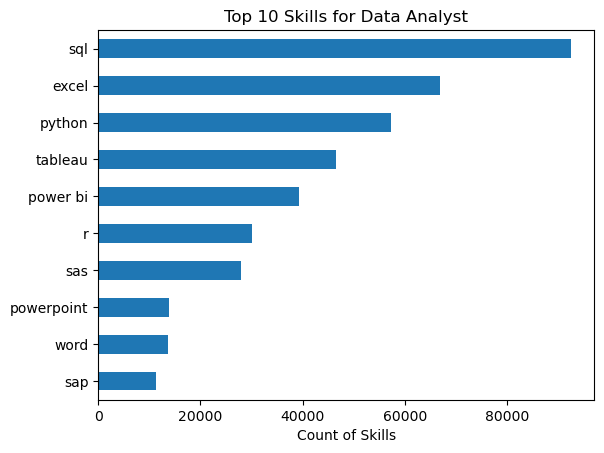

In [37]:
# 1. Configuration
target_role = 'Data Analyst'
top_n = 10

# 2. Filter and Explode
df_exploded = df[df['job_title_short'] == target_role].explode('job_skills')

# 3. Calculate Counts
# This creates a Series: Index = Skills, Values = Counts
skill_counts = df_exploded['job_skills'].value_counts().head(top_n)

# 4. Plotting
# We don't need x='' or y='' here because it's a Series
skill_counts.plot(
    kind='barh',
    title=f'Top {top_n} Skills for {target_role}',
    xlabel='Count of Skills',
    ylabel=''
)

plt.gca().invert_yaxis()
plt.show()